# 05 — Experiment D: Generalization ⭐

การทดลองหลักของโปรเจกต์ ตอบคำถามว่าโมเดล **จำ character หรือจำลักษณะของ source/font**

1. **Random split** — เทรนและทดสอบใน source เดียวกัน (in-domain baseline)
2. **Cross-source** — เทรน source หนึ่ง ทดสอบอีก source ที่ไม่เคยเห็น รวม 6 ทิศ
3. **Unseen font** — กันกลุ่มลายมือ/ฟอนต์ทั้งกลุ่มไว้เป็น test set
4. **Generalization gap** = in-domain − out-of-domain

In [1]:
import sys, json
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src.utils.common import load_config, thai_char, save_json, RESULTS_DIR
from src.datasets.thai_chars import load_data

plt.rcParams["figure.dpi"] = 110
try:
    plt.rcParams["font.family"] = "Thonburi"   # ฟอนต์ไทยที่มากับ macOS
except Exception:
    pass
print("ROOT:", ROOT)

ROOT: /Users/thiya/Documents/GitHub/Project-1-Thai-Character-Number-Recognition


In [2]:
from src.training.run_experiment import prepare, run_generalization

cfg = load_config(ROOT / "configs" / "generalization.yaml")
print("โมเดล:", cfg["model"], "| augmentation:", cfg["augmentation"], "| sources:", cfg["sources"])

โมเดล: mobilenet_v3_small | augmentation: thai_specific | sources: ['D1', 'D2', 'D3']


## รันจริง

เทรน 3 ครั้ง (source ละ 1 ครั้ง) แล้วเอาแต่ละโมเดลไปทดสอบกับอีก 2 source บวก unseen-font อีก 2 ครั้ง
รวมประมาณ 5 การเทรน ใช้เวลาราว 3–5 ชั่วโมง

ผลเขียนลง `experiments/generalization/` และ `results/tables/generalization.csv`

In [3]:
data = prepare(cfg)
rows = run_generalization(cfg, data)

ใช้ cache research_cache_96.npz: 163155 รูป

=== random split: D1 ===
  ตัดคลาสที่มีตัวอย่างน้อยกว่า 2: 163×1, 177×1, 208×1
[mobilenet_v3_small | aug=thai_specific] train 49912 | val 6239 | 81 classes | 1.6M params | mps
    ep1 step 0/389 loss 4.6369
    ep1 step 200/389 loss 1.2635
  epoch 1 train_loss 1.9033 train_acc 0.6845 sec 50.6231 val_acc 0.9441
    ep2 step 0/389 loss 0.9187
    ep2 step 200/389 loss 0.8678
  epoch 2 train_loss 0.8696 train_acc 0.9689 sec 45.9443 val_acc 0.9764
    ep3 step 0/389 loss 0.8046
    ep3 step 200/389 loss 0.8148
  epoch 3 train_loss 0.8303 train_acc 0.9788 sec 47.1319 val_acc 0.9832
    ep4 step 0/389 loss 0.8096
    ep4 step 200/389 loss 0.8021
  epoch 4 train_loss 0.8154 train_acc 0.9817 sec 54.8376 val_acc 0.9883
    ep5 step 0/389 loss 0.7987
    ep5 step 200/389 loss 0.7745
  epoch 5 train_loss 0.8057 train_acc 0.9853 sec 65.6191 val_acc 0.9875
    ep6 step 0/389 loss 0.8020
    ep6 step 200/389 loss 0.7969
  epoch 6 train_loss 0.8000 train_a

## Cross-Source Matrix (README ข้อ 10)

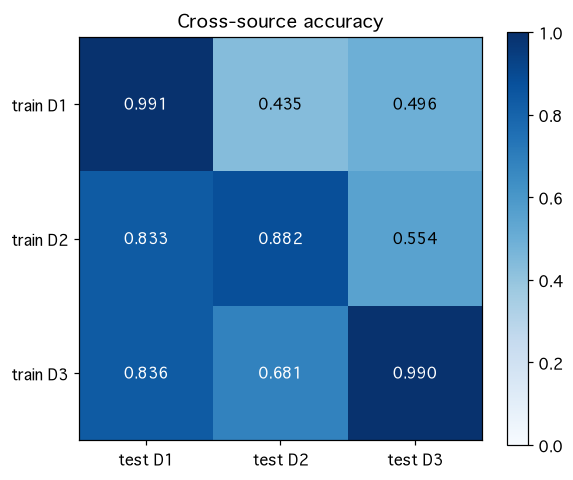

In [4]:
matrix = json.loads((RESULTS_DIR / "tables" / "cross_source_matrix.json").read_text())
srcs = cfg["sources"]
M = np.full((len(srcs), len(srcs)), np.nan)
for k, v in matrix.items():
    a, b = k.split("->")
    M[srcs.index(a), srcs.index(b)] = v

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(M, cmap="Blues", vmin=0, vmax=1)
for i in range(len(srcs)):
    for j in range(len(srcs)):
        if not np.isnan(M[i, j]):
            ax.text(j, i, f"{M[i, j]:.3f}", ha="center", va="center",
                    color="white" if M[i, j] > 0.6 else "black")
ax.set_xticks(range(len(srcs)), [f"test {s}" for s in srcs])
ax.set_yticks(range(len(srcs)), [f"train {s}" for s in srcs])
ax.set_title("Cross-source accuracy")
plt.colorbar(im); plt.tight_layout()
plt.savefig(RESULTS_DIR / "figures" / "cross_source_matrix.png", bbox_inches="tight")
plt.show()

## Generalization Gap

เทียบเส้นทแยง (in-domain) กับนอกเส้นทแยง (out-of-domain)
gap ยิ่งกว้าง แปลว่าโมเดลยิ่งติดลักษณะเฉพาะของ source ที่เทรน

In [5]:
import csv
rows = list(csv.DictReader(open(RESULTS_DIR / "tables" / "generalization.csv", encoding="utf-8")))
for r in rows:
    print(r)

gaps = [(r["train"], r["test"], float(r["gap"])) for r in rows
        if r["setting"] == "cross_source" and r.get("gap")]
if gaps:
    print(f"\ngap เฉลี่ย {np.mean([g[2] for g in gaps]):.3f} | "
          f"แย่สุด {max(gaps, key=lambda g: g[2])}")

{'setting': 'random_split', 'train': 'D1', 'test': 'D1', 'accuracy': '0.9909', 'macro_f1': '0.9814', 'gap': ''}
{'setting': 'cross_source', 'train': 'D1', 'test': 'D2', 'accuracy': '0.435', 'macro_f1': '0.3363', 'gap': '0.5558'}
{'setting': 'cross_source', 'train': 'D1', 'test': 'D3', 'accuracy': '0.4959', 'macro_f1': '0.4655', 'gap': '0.495'}
{'setting': 'random_split', 'train': 'D2', 'test': 'D2', 'accuracy': '0.8816', 'macro_f1': '0.8817', 'gap': ''}
{'setting': 'cross_source', 'train': 'D2', 'test': 'D1', 'accuracy': '0.833', 'macro_f1': '0.5405', 'gap': '0.0486'}
{'setting': 'cross_source', 'train': 'D2', 'test': 'D3', 'accuracy': '0.5545', 'macro_f1': '0.6588', 'gap': '0.3271'}
{'setting': 'random_split', 'train': 'D3', 'test': 'D3', 'accuracy': '0.9895', 'macro_f1': '0.9901', 'gap': ''}
{'setting': 'cross_source', 'train': 'D3', 'test': 'D1', 'accuracy': '0.8357', 'macro_f1': '0.673', 'gap': '0.1538'}
{'setting': 'cross_source', 'train': 'D3', 'test': 'D2', 'accuracy': '0.6808',

## สรุปผลที่ต้องเขียนลงรายงาน

1. in-domain accuracy ของแต่ละ source เป็นเท่าไร
2. cross-source ตกลงมาเท่าไร ทิศไหนแย่ที่สุด และเป็นเพราะอะไร
   (คลาสที่ขาด? ลายมือต่าง? resolution ต่าง?)
3. unseen font ตกลงมาเท่าไรเทียบกับ random split ของ source เดียวกัน
4. `thai_specific` augmentation ช่วยลด gap ได้ไหม — ลองรันซ้ำโดยเปลี่ยน `augmentation:` ใน config
   แล้วเทียบ gap ระหว่างสองรอบ

## Optional: Combined Training (README ข้อ 13)

เทรนด้วยทั้ง 3 source พร้อมกันแล้วทดสอบแยกแต่ละ source เพื่อตอบว่า
"การเห็นข้อมูลหลากหลายตอนเทรนช่วย generalization หรือไม่"

In [6]:
from src.datasets.splits import random_split
from src.training.run_experiment import train_and_eval
from src.evaluation.metrics import evaluate_split
from src.utils.common import get_device

split = random_split(data, sources=None, val_ratio=0.1, test_ratio=0.1, seed=cfg["seed"])
model, result, metrics = train_and_eval(data, split, cfg, cfg["model"], cfg["augmentation"],
                                        "generalization", "combined_all_sources")
device = get_device(cfg.get("device", "auto"))
for s in cfg["sources"]:
    m = evaluate_split(model, data, data.where(sources=s), device, data.classes)
    print(f"combined -> {s}: acc {m['accuracy']:.4f} | macro F1 {m['macro_f1']:.4f}")

[mobilenet_v3_small | aug=thai_specific] train 130523 | val 16316 | 81 classes | 1.6M params | mps
    ep1 step 0/1019 loss 4.4604
    ep1 step 200/1019 loss 3.4563
    ep1 step 400/1019 loss 1.6995
    ep1 step 600/1019 loss 1.5517
    ep1 step 800/1019 loss 1.2017
    ep1 step 1000/1019 loss 1.2320
  epoch 1 train_loss 2.1366 train_acc 0.6148 sec 154.5518 val_acc 0.8867
    ep2 step 0/1019 loss 1.3008
    ep2 step 200/1019 loss 1.0811
    ep2 step 400/1019 loss 1.0515
    ep2 step 600/1019 loss 1.0806
    ep2 step 800/1019 loss 1.1618
    ep2 step 1000/1019 loss 1.2335
  epoch 2 train_loss 1.1530 train_acc 0.8859 sec 153.4278 val_acc 0.9103
    ep3 step 0/1019 loss 1.0731
    ep3 step 200/1019 loss 1.2692
    ep3 step 400/1019 loss 1.1109
    ep3 step 600/1019 loss 1.0809
    ep3 step 800/1019 loss 1.0973
    ep3 step 1000/1019 loss 1.0095
  epoch 3 train_loss 1.0760 train_acc 0.9068 sec 170.7721 val_acc 0.9226
    ep4 step 0/1019 loss 1.0913
    ep4 step 200/1019 loss 0.9920
    ep4